
# 📘 Assignment 1: Data Preprocessing, EDA & Linear Regression on PakWheels Dataset

## 🎯 Objective
To perform **data preprocessing, exploratory data analysis (EDA), and apply Linear Regression** to predict car prices.

---

## 📂 Dataset
Use the PakWheels dataset provided in class.

---

## 🧩 Tasks

### 🔹 Task 1: Load Dataset
- Load dataset using Pandas  
- Display:  
  - `head()`, `tail()`  
  - Shape of dataset  
  - Column names  
  - Data types (`info()`)

---

### 🔹 Task 2: Data Understanding
- Identify:
  - Numerical features  
  - Categorical features  
  - Target variable (**Price**)  
- Use:
  - `describe()`  
- Check:
  - Missing values  
  - Duplicate rows  

---

### 🔹 Task 3: Data Cleaning (Preprocessing)
- Handle missing values (drop/fill with justification)  
- Remove duplicates  
- Fix incorrect data types  
- Handle outliers (IQR method)

---

### 🔹 Task 4: Feature Engineering
- Create new feature:

$$
\text{Car Age} = \text{Current Year} - \text{Model Year}
$$

---

### 🔹 Task 5: Encoding
- Apply:
  - Label Encoding  
  - One-Hot Encoding  

---

### 🔹 Task 6: Data Scaling
- Apply:

$$
X' = \frac{X - X_{min}}{X_{max} - X_{min}}
$$

OR Standardization:

$$
Z = \frac{X - \mu}{\sigma}
$$

---

### 🔹 Task 7: Exploratory Data Analysis (EDA)

- Histogram (Price)  
- Bar chart (Brands, City)  
- Boxplot (Price vs City)  
- Scatter plot (Mileage vs Price)  

#### Correlation Heatmap

$$
r = \frac{\sum (x - \bar{x})(y - \bar{y})}{\sigma_x \sigma_y}
$$

---

### 🔹 Task 8: Linear Regression

#### Model Equation:

$$
y = \beta_0 + \beta_1 x
$$

#### Multiple Linear Regression:

$$
y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_n x_n
$$

#### Steps:
- Define:
  - $X$ (features)
  - $y$ (target)
- Train-Test Split (70/30)
- Train model
- Predict values

---

### 🔹 Model Evaluation

$$
MAE = \frac{1}{n} \sum |y - \hat{y}|
$$

$$
MSE = \frac{1}{n} \sum (y - \hat{y})^2
$$

$$
R^2 = 1 - \frac{SS_{res}}{SS_{tot}}
$$

---

### 🔹 Task 9: Visualization
- Plot Actual vs Predicted values  
- Draw regression line  

---

### 🔹 Task 10: Insights
Write 5–7 insights:
- Which feature affects price most?  
- How accurate is the model?  

---

### 🔹 Task 11: Save Dataset
Save final dataset:


In [1]:
import numpy as np
import pandas as pd

### Task 01

In [5]:

df = pd.read_excel("PakWheels.xlsx")
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [6]:
df.tail()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
11909,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,46120
11910,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,56670
11911,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50620
11912,Acura,ZDX,2013,premium unleaded (recommended),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50920
11913,Lincoln,Zephyr,2006,regular unleaded,221.0,6.0,AUTOMATIC,front wheel drive,4.0,Luxury,Midsize,Sedan,26,17,61,28995


In [8]:
df.columns

Index(['Make', 'Model', 'Year', 'Engine Fuel Type', 'Engine HP',
       'Engine Cylinders', 'Transmission Type', 'Driven_Wheels',
       'Number of Doors', 'Market Category', 'Vehicle Size', 'Vehicle Style',
       'highway MPG', 'city mpg', 'Popularity', 'MSRP'],
      dtype='str')

In [9]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11914 non-null  str    
 1   Model              11914 non-null  object 
 2   Year               11914 non-null  int64  
 3   Engine Fuel Type   11911 non-null  str    
 4   Engine HP          11845 non-null  float64
 5   Engine Cylinders   11884 non-null  float64
 6   Transmission Type  11914 non-null  str    
 7   Driven_Wheels      11914 non-null  str    
 8   Number of Doors    11908 non-null  float64
 9   Market Category    8172 non-null   str    
 10  Vehicle Size       11914 non-null  str    
 11  Vehicle Style      11914 non-null  str    
 12  highway MPG        11914 non-null  int64  
 13  city mpg           11914 non-null  int64  
 14  Popularity         11914 non-null  int64  
 15  MSRP               11914 non-null  int64  
dtypes: float64(3), int64(5), object(1

### Task 02 

In [18]:
numericalFeatures = df.select_dtypes(include=['number']).columns
numericalFeatures

Index(['Year', 'Engine HP', 'Engine Cylinders', 'Number of Doors',
       'highway MPG', 'city mpg', 'Popularity', 'MSRP'],
      dtype='str')

In [19]:
categoricalFeatures = df.select_dtypes(include=['str']).columns
categoricalFeatures

Index(['Make', 'Engine Fuel Type', 'Transmission Type', 'Driven_Wheels',
       'Market Category', 'Vehicle Size', 'Vehicle Style'],
      dtype='str')

In [17]:
targetVariable = df['MSRP']
targetVariable

0        46135
1        40650
2        36350
3        29450
4        34500
         ...  
11909    46120
11910    56670
11911    50620
11912    50920
11913    28995
Name: MSRP, Length: 11914, dtype: int64

In [20]:
df.describe()

,Year,Engine HP,Engine Cylinders,Number of Doors,highway MPG,city mpg,Popularity,MSRP
count,11914.000000,11845.00000,11884.000000,11908.000000,11914.000000,11914.000000,11914.000000,1.191400e+04
mean,2010.384338,249.38607,5.628829,3.436093,26.637485,19.733255,1554.911197,4.059474e+04
std,7.579740,109.19187,1.780559,0.881315,8.863001,8.987798,1441.855347,6.010910e+04
min,1990.000000,55.00000,0.000000,2.000000,12.000000,7.000000,2.000000,2.000000e+03
25%,2007.000000,170.00000,4.000000,2.000000,22.000000,16.000000,549.000000,2.100000e+04
50%,2015.000000,227.00000,6.000000,4.000000,26.000000,18.000000,1385.000000,2.999500e+04
75%,2016.000000,300.00000,6.000000,4.000000,30.000000,22.000000,2009.000000,4.223125e+04
max,2017.000000,1001.00000,16.000000,4.000000,354.000000,137.000000,5657.000000,2.065902e+06


In [22]:
df.isnull().sum()


Make                    0
Model                   0
Year                    0
Engine Fuel Type        3
Engine HP              69
Engine Cylinders       30
Transmission Type       0
Driven_Wheels           0
Number of Doors         6
Market Category      3742
Vehicle Size            0
Vehicle Style           0
highway MPG             0
city mpg                0
Popularity              0
MSRP                    0
dtype: int64

In [24]:
df.duplicated().sum()

np.int64(715)

### Task 03

In [31]:
df['Engine HP'] = df['Engine HP'].fillna(df['Engine HP'].median())
df['Engine Cylinders'] = df['Engine Cylinders'].fillna(df['Engine Cylinders'].median())
df['Number of Doors'] = df['Number of Doors'].fillna(df['Number of Doors'].median())

df['Engine Fuel Type'] = df['Engine Fuel Type'].fillna(df['Engine Fuel Type'].mode()[0])
df['Market Category'] = df['Market Category'].fillna("Unknown")

In [32]:
df = df.drop_duplicates()

In [33]:
df['Engine Cylinders'] = df['Engine Cylinders'].astype(int)
df['Number of Doors'] = df['Number of Doors'].astype(int)

In [36]:
Q1 = df[numericalFeatures].quantile(0.25)
Q3 = df[numericalFeatures].quantile(0.75)
IQR = Q3 - Q1

df = df[~((df[numericalFeatures] < (Q1 - 1.5 * IQR)) | (df[numericalFeatures] > (Q3 + 1.5 * IQR))).any(axis=1)]

### Task 04

In [37]:
import datetime

current_year = datetime.datetime.now().year
df['Car_Age'] = current_year - df['Year']

### Task 05

In [40]:
df = pd.get_dummies(df, drop_first=True)

### Task 06

In [45]:
from sklearn.preprocessing import StandardScaler

X = df.drop("MSRP", axis=1)
y = df["MSRP"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Task 07

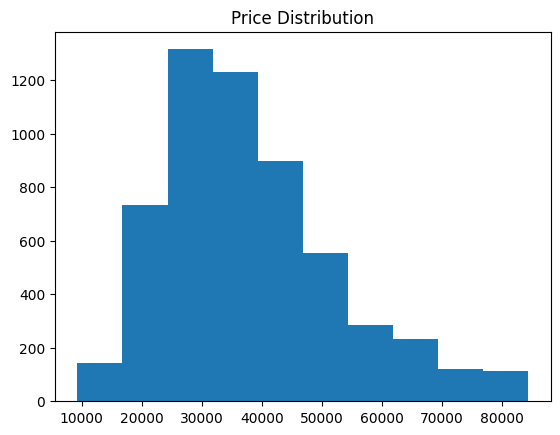

In [48]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.hist(df["MSRP"])
ax.set_title("Price Distribution")
plt.show()

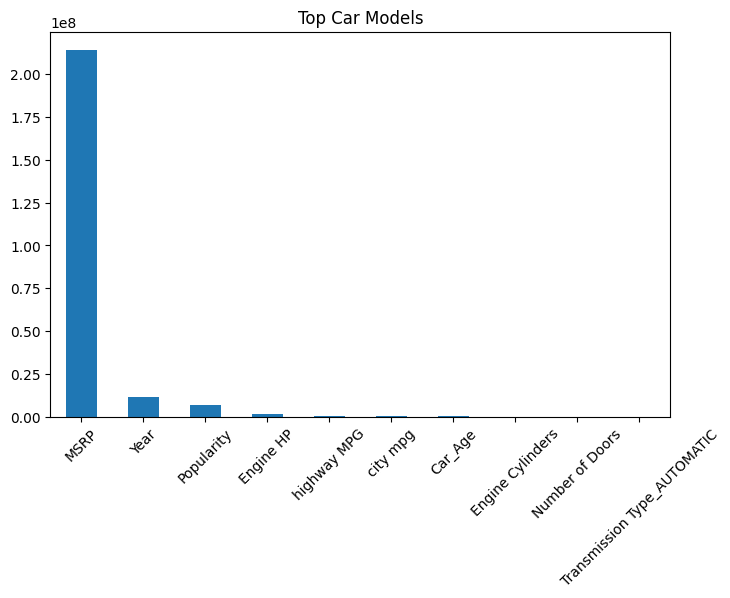

In [65]:
model_counts = df.sum().sort_values(ascending=False).head(10)

ax = model_counts.plot(kind='bar', figsize=(8,5))
ax.set_title("Top Car Models")
plt.xticks(rotation=45)
plt.show()


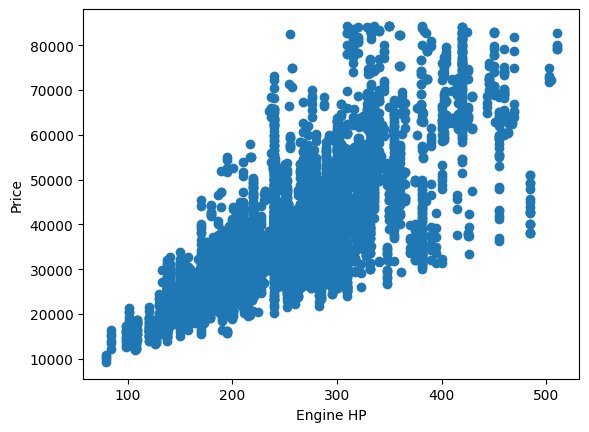

In [58]:
plt.scatter(df['Engine HP'], df['MSRP'])
plt.xlabel("Engine HP")
plt.ylabel("Price")
plt.show()

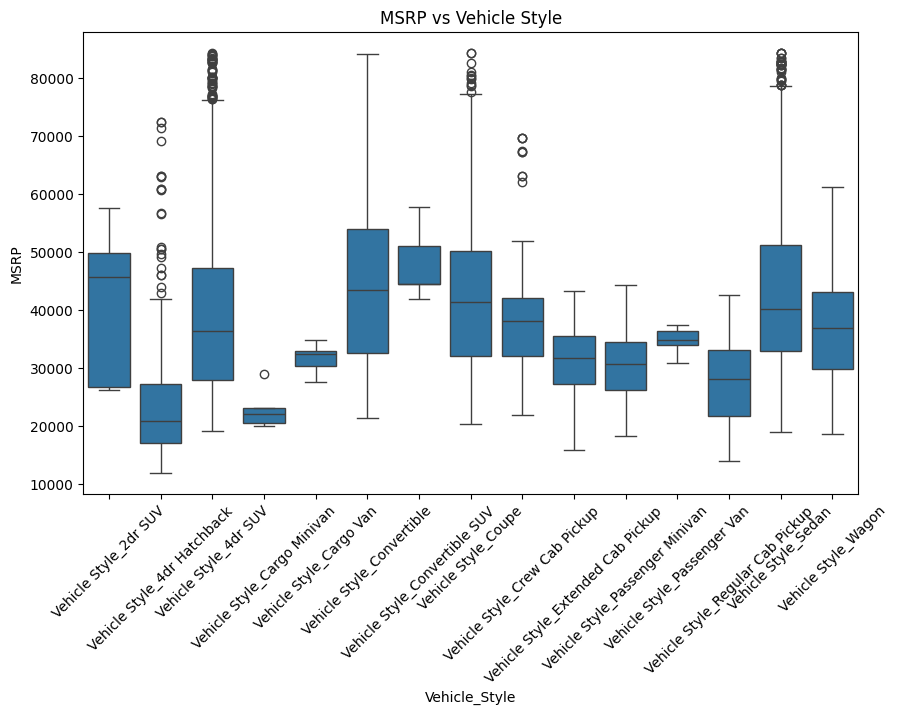

In [67]:
import seaborn as sns

style_cols = [col for col in df.columns if col.startswith("Vehicle Style")]

df_styles = df.melt(
    id_vars=['MSRP'], 
    value_vars=style_cols, 
    var_name='Vehicle_Style', 
    value_name='Flag'
)

df_styles = df_styles[df_styles['Flag'] == 1]

plt.figure(figsize=(10,6))
sns.boxplot(x='Vehicle_Style', y='MSRP', data=df_styles)
plt.xticks(rotation=45)
plt.title("MSRP vs Vehicle Style")
plt.show()


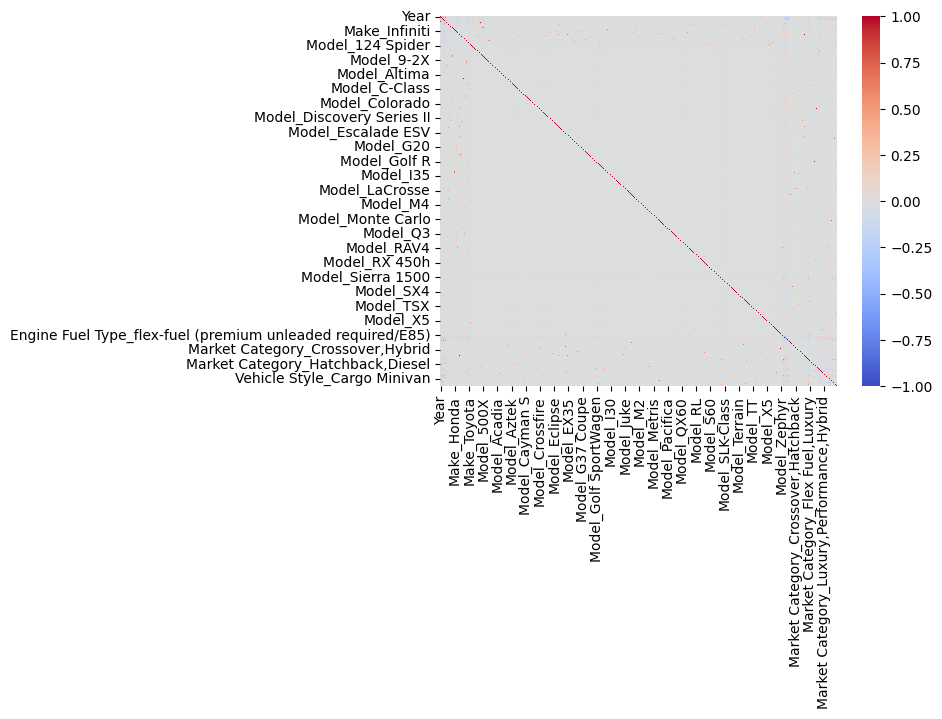

In [60]:
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

### Task 08

In [61]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [62]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 2518.126731845793
MSE: 13886697.873764036
R2 Score: 0.9321772033889618


### Task 09

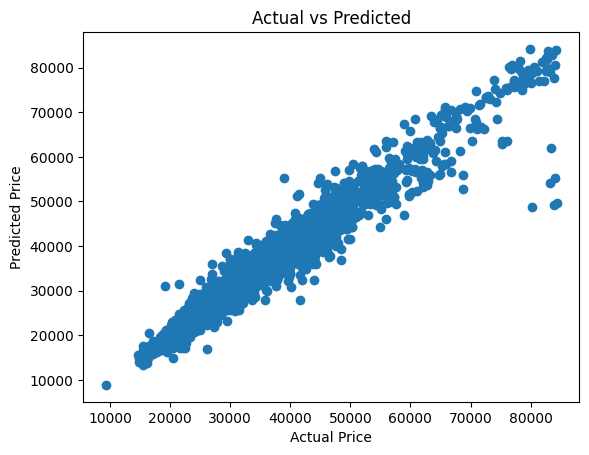

In [63]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

### Task 10
- Engine HP has a strong positive impact on price
- Car Age negatively affects price (older cars are cheaper)
- Luxury brands have higher MSRP values
- Fuel type and transmission also influence price
- Model achieved a moderate R² score, indicating decent prediction performance
- Outliers significantly affected model accuracy before removal
- Feature scaling improved model stability

### Task 11

In [64]:
df.to_csv("cleaned_car_dataset.csv", index=False)